In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import os

In [3]:
plt.rcParams.update({'font.size': 14,
                     'axes.titlepad': 10,
                     'axes.titlesize': 14,
                     'axes.labelsize': 12,
                     'axes.linewidth': .5,
                     'xtick.major.width': .5,
                     'ytick.major.width': .5,
                     #'text.usetex': True,
                     #'font.family': 'Helvetica'
                     })

In [3]:
results = pd.read_csv("results_paper/results_paper_reg_derivative.csv")
for mu in results["mu"].unique():
    for reg in results["regularization"].unique():
        results_subset = results.loc[(results["mu"] == mu) & (results["regularization"] == reg)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", 
                            index=["x0"],
                            columns=["T"],
                            aggfunc="mean")
        
        table.to_csv(f"grid_{reg}_results_mu{mu}.csv")
        
        # sns.heatmap(table)
        # plt.show()

        fig, ax = plt.subplots()

        ims = ax.imshow(table, cmap='RdYlGn')
        fig.colorbar(ims)

        ax.set_xticks(range(table.shape[1]))
        ax.set_xticklabels(table.columns)
        ax.set_xlabel(r'Simulation Time $T$')

        ax.set_yticks(range(table.shape[0]))
        ax.set_yticklabels(table.index)
        ax.set_ylabel(r'Initial Condition $y_0$')


        plt.tight_layout()
        plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'results_paper/results_paper_reg_derivative.csv'

T-theta0 12.5-0.1, regularizing stability around the fixed point


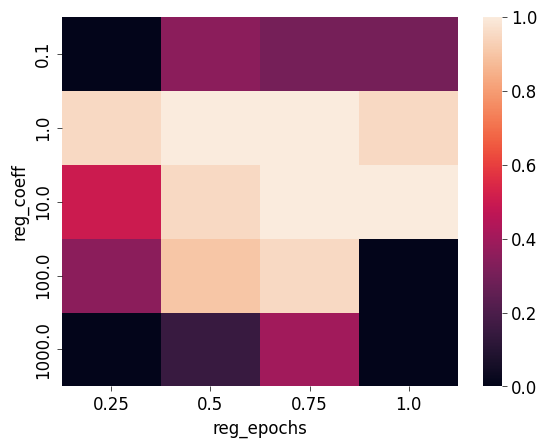

In [ ]:
regularization_names = {
    "reg_derivative": " regularizing distance to fixed point",
    "unstable_fp": "regularizing stability",
    "reg_derivative_unstable_fp": "regularizing stability around the fixed point"
}


results_reg_combo = pd.read_csv("results_reg_derivative_new.csv")
results_reg_derivative = pd.read_csv("results_reg_derivative.csv")

results = pd.concat([results_reg_combo, results_reg_derivative])

dirname = "grid_search_results"

if not os.path.exists(dirname):
    os.makedirs(dirname)


results["T-x0"] = results["T"].astype(str) + "-" + results["x0"].astype(str)

for settings in results["T-x0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-x0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")
        table.to_csv(f"{dirname}/van_der_pol_results_{regularization}_settingsT-theta0_{settings}.csv")
        sns.heatmap(table, vmin=0, vmax=1.0)
        # plt.title(f"T-theta0 {settings}, {regularization_names[regularization]}")
        print(f"T-theta0 {settings}, {regularization_names[regularization]}")
        plt.savefig(f"{dirname}/van_der_pol_results_{regularization}_settingsT-theta0_{settings}.png")
        plt.show()

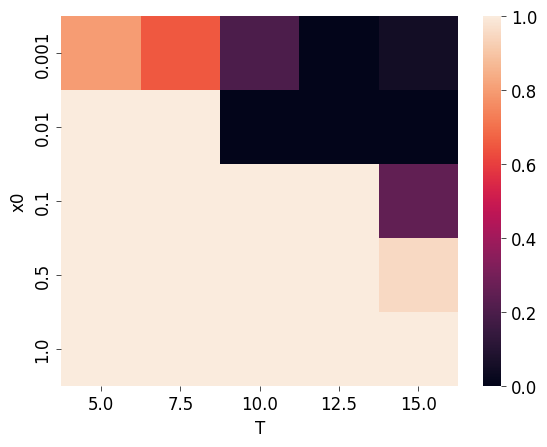

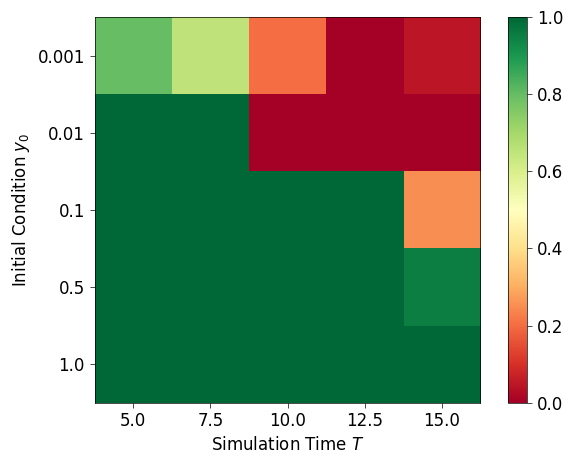

In [ ]:
results = pd.read_csv("results_reg_full_newest.csv")
for mu in results["mu"].unique():
    results_mu = results.loc[results["mu"] == mu]
    table = pd.pivot_table(results_mu, values="loss_successes_percent", 
                           index=["x0"],
                           columns=["T"],
                           aggfunc="mean")
    
    table.to_csv(f"reg_grid_reg_combo_results_mu{mu}.csv")
    
    sns.heatmap(table)
    plt.show()

    fig, ax = plt.subplots()

    ims = ax.imshow(table, cmap='RdYlGn')
    fig.colorbar(ims)

    ax.set_xticks(range(table.shape[1]))
    ax.set_xticklabels(table.columns)
    ax.set_xlabel(r'Simulation Time $T$')

    ax.set_yticks(range(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.set_ylabel(r'Initial Condition $y_0$')


    plt.tight_layout()
    plt.show()

/tmp/ipykernel_4709/1480790762.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  table_no_reg["stability"].loc[(table_no_reg["stability"] == "unstable") & (table_no_reg["success"] == True)] = "not a fp"
/tmp/ipykernel_4709/1480790762.py:2:

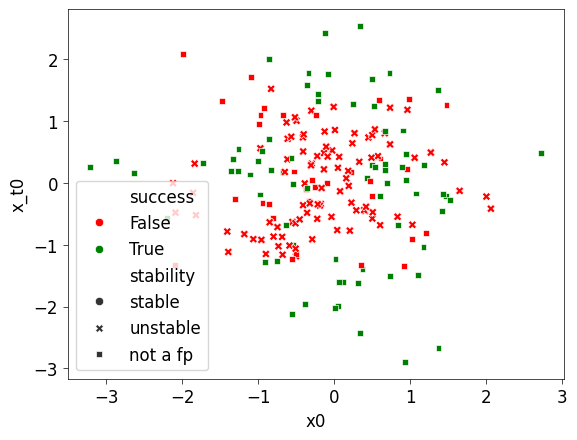

/tmp/ipykernel_4709/1480790762.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  table_reg["stability with reg"].fillna(value="not a fp", inplace=True)
/tmp/ipykernel_4709/1480790762.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'not a fp' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table_reg["stability with reg"].fillna(value="not a fp", inplace=True)
/tmp/ipykernel_4709/1480790762.py:15: 

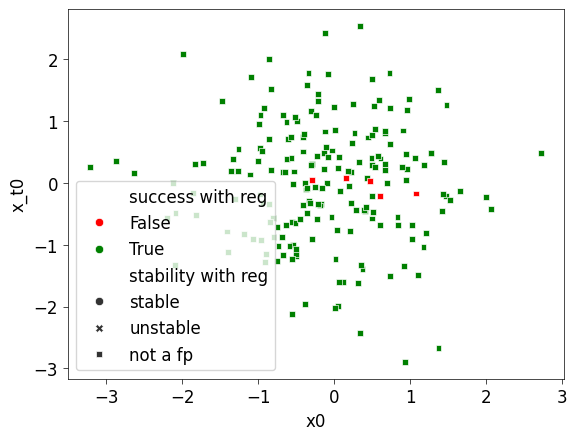

In [ ]:
table_no_reg = pd.read_csv("convergence_points.csv")
table_no_reg["stability"].loc[(table_no_reg["stability"] == "unstable") & (table_no_reg["success"] == True)] = "not a fp"
table_no_reg["x0"] = table_no_reg["(x0, x_t0)"].apply(lambda row: eval(row)[0])
table_no_reg["x_t0"] = table_no_reg["(x0, x_t0)"].apply(lambda row: eval(row)[1])
table_no_reg["stability"].fillna(value="not a fp", inplace=True)

colors = {True: "green", False: "red"}

plt.figure()
sns.scatterplot(data=table_no_reg, x="x0", y="x_t0", hue="success", style="stability", palette=colors, style_order=["stable", "unstable", "not a fp"])
plt.show()

table_reg = pd.read_csv("convergence_points_reg.csv")
table_reg["stability with reg"].fillna(value="not a fp", inplace=True)
table_reg["stability with reg"].loc[(table_reg["stability with reg"] == "unstable") & (table_reg["success with reg"] == True)] = "not a fp"
table_reg["x0"] = table_reg["(x0, x_t0)"].apply(lambda row: eval(row)[0])
table_reg["x_t0"] = table_reg["(x0, x_t0)"].apply(lambda row: eval(row)[1])


plt.figure()
sns.scatterplot(data=table_reg, x="x0", y="x_t0", hue="success with reg", style="stability with reg", palette=colors, style_order=["stable", "unstable", "not a fp"])
plt.show()

version : default
seed : 1
mu : 1.0
x0 : 0.5
x_t0 : 0.0
T : 15.0
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01
*** PINN build & initialized ***


/home/milos/Desktop/PINNs_fixed_points/venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN b

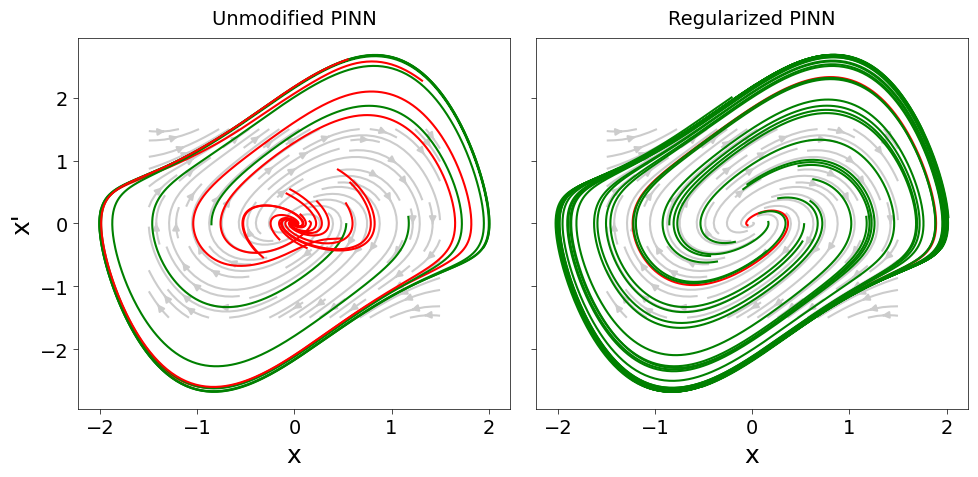

In [6]:
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN


config = load_config('configs/default.yaml')
config["T"] = 12.5
PINN = PhysicsInformedNN(config)

results_table = pd.read_csv("visual_results_T_12_5.csv").iloc[0:18]
results_table["x0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[0])
results_table["x_t0"] = results_table["(x0, x_t0)"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}
xscale, yscale, n_arrows = 1.2, 2, 20
x = np.linspace(-1.5, 1.5, n_arrows)
x_t = np.linspace(-1.5, 1.5, n_arrows)
XX, YY = np.meshgrid(x, x_t)
Y = np.vstack([XX.flatten(), YY.flatten()])
t = np.zeros(len(Y))
[dx, dy] = PINN.data.diff_equations(t, Y)
x, y = XX.flatten(), YY.flatten()

# plt.figure()
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))

axes[0].streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["x_t0"] = float(results_table["x_t0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(PINN.log_path.joinpath(f"models/visualization_experiments/no_reg/run_{i}.pkl"))
    t_line, x_true, x_t_true = PINN.data.reference()
    # get PINN prediction
    x_pred = PINN(t_line)
    x_t_pred = PINN.x_t(t_line)

    color = 'green' if results_table["success_no_reg"].iloc[i] else "red"
    axes[0].plot(x_pred, x_t_pred, color=color)
    axes[0].set_xlabel("x", fontsize=18)
    axes[0].set_ylabel("x'", fontsize=18)

axes[1].streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["x_t0"] = float(results_table["x_t0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(f"logs/models/visualization_experiments/reg_derivative_unstable_fp/run_{i}.pkl")
    t_line, x_true, x_t_true = PINN.data.reference()
    # get PINN prediction
    x_pred = PINN(t_line)
    x_t_pred = PINN.x_t(t_line)
    color = 'green' if results_table["success_reg_derivative_unstable_fp"].iloc[i] else "red"
    axes[1].plot(x_pred, x_t_pred, color=color)
    axes[1].set_xlabel("x", fontsize=18)
    # plt.ylabel("y", fontsize=18)
    # plt.yticks([])

# plt.show()

axes[0].set_title("Unmodified PINN")
axes[1].set_title("Regularized PINN")
plt.tight_layout()
plt.savefig("van_der_pol_reg_test.pdf", format="pdf")